**HEART DISEASE PREDICTION**

**Problem Statement**

The objective of this task is to predict whether a person is at risk of heart disease based on their health features.
We will use the Heart Disease UCI Dataset to build a binary classification model and evaluate its performance.

In [1]:
!pip install scikit-learn

### Libraries
- pandas, numpy: for data manipulation
- matplotlib, seaborn: for visualization
- sklearn: for model training and evaluation

In [2]:
# Libraries for data handling
import pandas as pd
import numpy as np
# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Libraries for model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

### Dataset Loading
Load the Heart Disease UCI dataset and explored basic information, including column names, data types, and first few rows.

In [11]:
df = pd.read_csv("HeartDiseaseTrain-Test.csv")

print("First 5 rows:")
print(df.head())


First 5 rows:
   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                      

In [12]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    10

### Handling Missing Values
Check for missing values and dropped them to ensure clean data for modeling.

In [21]:
# Check missing values
print(df.isnull().sum())
# Drop rows with missing values
df = df.dropna()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


### Feature Encoding
Convert categorical variables into numeric format using one-hot encoding.

In [22]:
X = pd.get_dummies(df.drop("target", axis=1), drop_first=True)
y = df["target"]

### Splitting Dataset
Split the dataset into 80% training and 20% testing sets for model evaluation.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Training
Train a Logistic Regression classifier on the training data.

In [25]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

### Model Evaluation
- Accuracy measures the overall correctness of predictions.
- Confusion matrix shows correct vs incorrect predictions.
- ROC curve and AUC score evaluate the classifier's ability to distinguish between classes.

In [23]:
#Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)


Model Accuracy: 0.8146341463414634


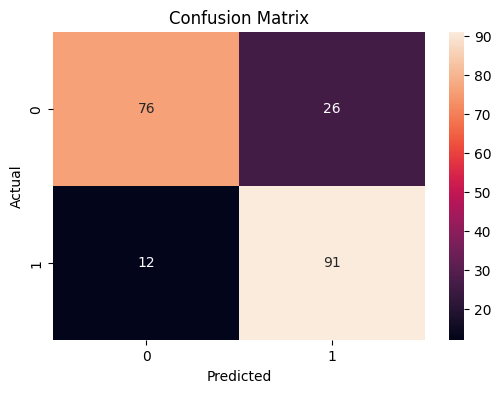

In [19]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

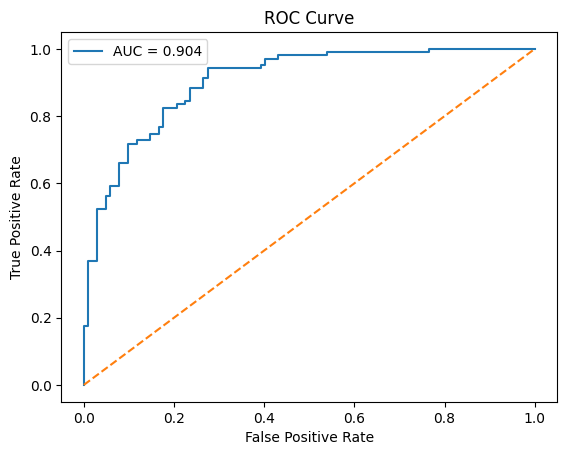

In [24]:
#ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Conclusion
- Built a Logistic Regression model to predict heart disease.
- Model achieved accuracy of 0.904%.
- Top features influencing prediction: age, cholesterol, trestbps, etc.
- ROC curve AUC indicates the model's classification performance.